# Step 1.3

Add visibility and bottom oxygen data to the map

The second part of this notebook had to be executed for each map resolution separately.

We only proceed with resolution 5x5, 3x3 and 1x1, as higher resolutions creates files that are too large

In [1]:
import os
import pandas
import datetime


import new_artist as artist

import data_pers
import plots
import read_data

import suntime

import numpy
from numpy import array, log, exp, mean, std, linspace
from math import isnan
import netCDF4

import pandas

from useful import rnorm
from scipy import stats

import random

/home/shubin/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/shubin/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


# Load environmental covariates

In [2]:
def read_variable_raw(year, name, filename=None):
    filename = filename or name
    nc = netCDF4.Dataset(f"/home/shubin/Downloads/obamanext/variables/{year}/{filename}.nc")
    try:
        LAT = [float(x) for x in nc.variables['lat'][:].data]
        LON = [float(x) for x in nc.variables['lon'][:].data]
        TIME = [datetime.date(1900, 1, 1) + datetime.timedelta(days=x) for x in nc.variables['time'][:]]
    except:
        LAT = [float(x) for x in nc.variables['latitude'][:].data]
        LON = [float(x) for x in nc.variables['longitude'][:].data]
        TIME = [datetime.date(1970, 1, 1) + datetime.timedelta(seconds=x) for x in nc.variables['time'][:]]
    try:
        if name == 'oxygen':
            MAP = nc.variables['o2'][:, 0]
        elif name == 'bottom_oxygen':
            MAP = nc.variables['o2b']
                
        elif name == 'transparency':
            MAP = nc.variables['zsd']
        elif name == 'salinity':
            if 'so' in nc.variables:
                MAP = nc.variables['so'][:, 0]
            else:
                MAP = nc.variables['siconc']
        elif name == 'temperature':
            MAP = nc.variables['thetao'][:, 0]
        elif name == 'depth':
            MAP = nc.variables['depth']                
            
        elif name == 'chlorophyll_spring':
            MAP = nc.variables['chl'][:, 0]
        elif name == 'chlorophyll_summer':
            MAP = nc.variables['chl'][:, 0]
        elif name == 'depth':
            MAP = nc.variables['depth']                
                
                
        elif name == 'ice_fraction':
            MAP = nc.variables['siconc']
        elif name == 'ice_thickness':
            MAP = nc.variables['sithick']
        else:
            print(nc.variables.keys())
            raise
    except:
        print(year)
        print(nc.variables.keys())
        raise
    
    print(MAP.shape)
    return MAP, TIME, LAT, LON



def read_variable_raw_mean(year, name, filename=None):
    MAPS, TIME, LAT, LON = read_variable_raw(year, name, filename)
    try:
        MAP = MAPS.mean(axis=0)
    except:
        MAP = numpy.mean(MAPS, axis=0)
        MAP.mask = numpy.mean(MAPS[:].mask, axis=0)

    return MAP, LAT, LON, TIME



def read_variable_as_flat_mean(year, name, filename=None):
    MAP, LAT, LON, TIME = read_variable_raw_mean(year, name, filename)

    FLAT, COORDS = [], []
    MASK = MAP.mask
    for i, lat in enumerate(LAT):
        for j, lon in enumerate(LON):
                if not MASK[i, j]:
                    FLAT.append(float(MAP[i, j]))
                    COORDS.append((lon, lat))
    print(var, year, len(FLAT), f'{min(TIME)}--{max(TIME)}', f'{min(FLAT)} -- {max(FLAT)}')
    return FLAT, COORDS



In [3]:
#YEARS = list(range(2008, 2022))
YEARS = list(range(2007, 2024))
RAW_DATA_MEAN = {}


In [4]:
var = 'transparency'
for year in YEARS:
    assert os.path.exists(f"/home/shubin/Downloads/obamanext/variables/{year}/{var}.nc")
    FLAT, COORDS = read_variable_as_flat_mean(year, var)
    RAW_DATA_MEAN[var, year] = FLAT, COORDS


(47, 774, 763)
transparency 2007 147134 2007-09-15--2007-10-31 1.0605571269989014 -- 14.257445335388184
(47, 773, 763)
transparency 2008 147133 1970-01-01--1970-01-01 1.1058481931686401 -- 14.200815200805664
(47, 773, 763)
transparency 2009 147133 1970-01-01--1970-01-01 1.0961284637451172 -- 14.540308952331543
(47, 773, 763)
transparency 2010 147133 1970-01-01--1970-01-01 1.1103355884552002 -- 14.927997589111328
(47, 773, 763)
transparency 2011 147133 1970-01-01--1970-01-01 1.0399399995803833 -- 14.779953956604004
(47, 773, 763)
transparency 2012 147133 1970-01-01--1970-01-01 1.096158742904663 -- 14.706625938415527
(47, 773, 763)
transparency 2013 147133 1970-01-01--1970-01-01 1.1308963298797607 -- 15.171259880065918
(47, 773, 763)
transparency 2014 147133 1970-01-01--1970-01-01 0.9743192195892334 -- 14.548147201538086
(32, 774, 763)
transparency 2015 147134 2015-09-28--2015-10-29 1.1546918153762817 -- 14.294660568237305
(44, 774, 763)
transparency 2016 147134 2016-09-13--2016-10-26 1.

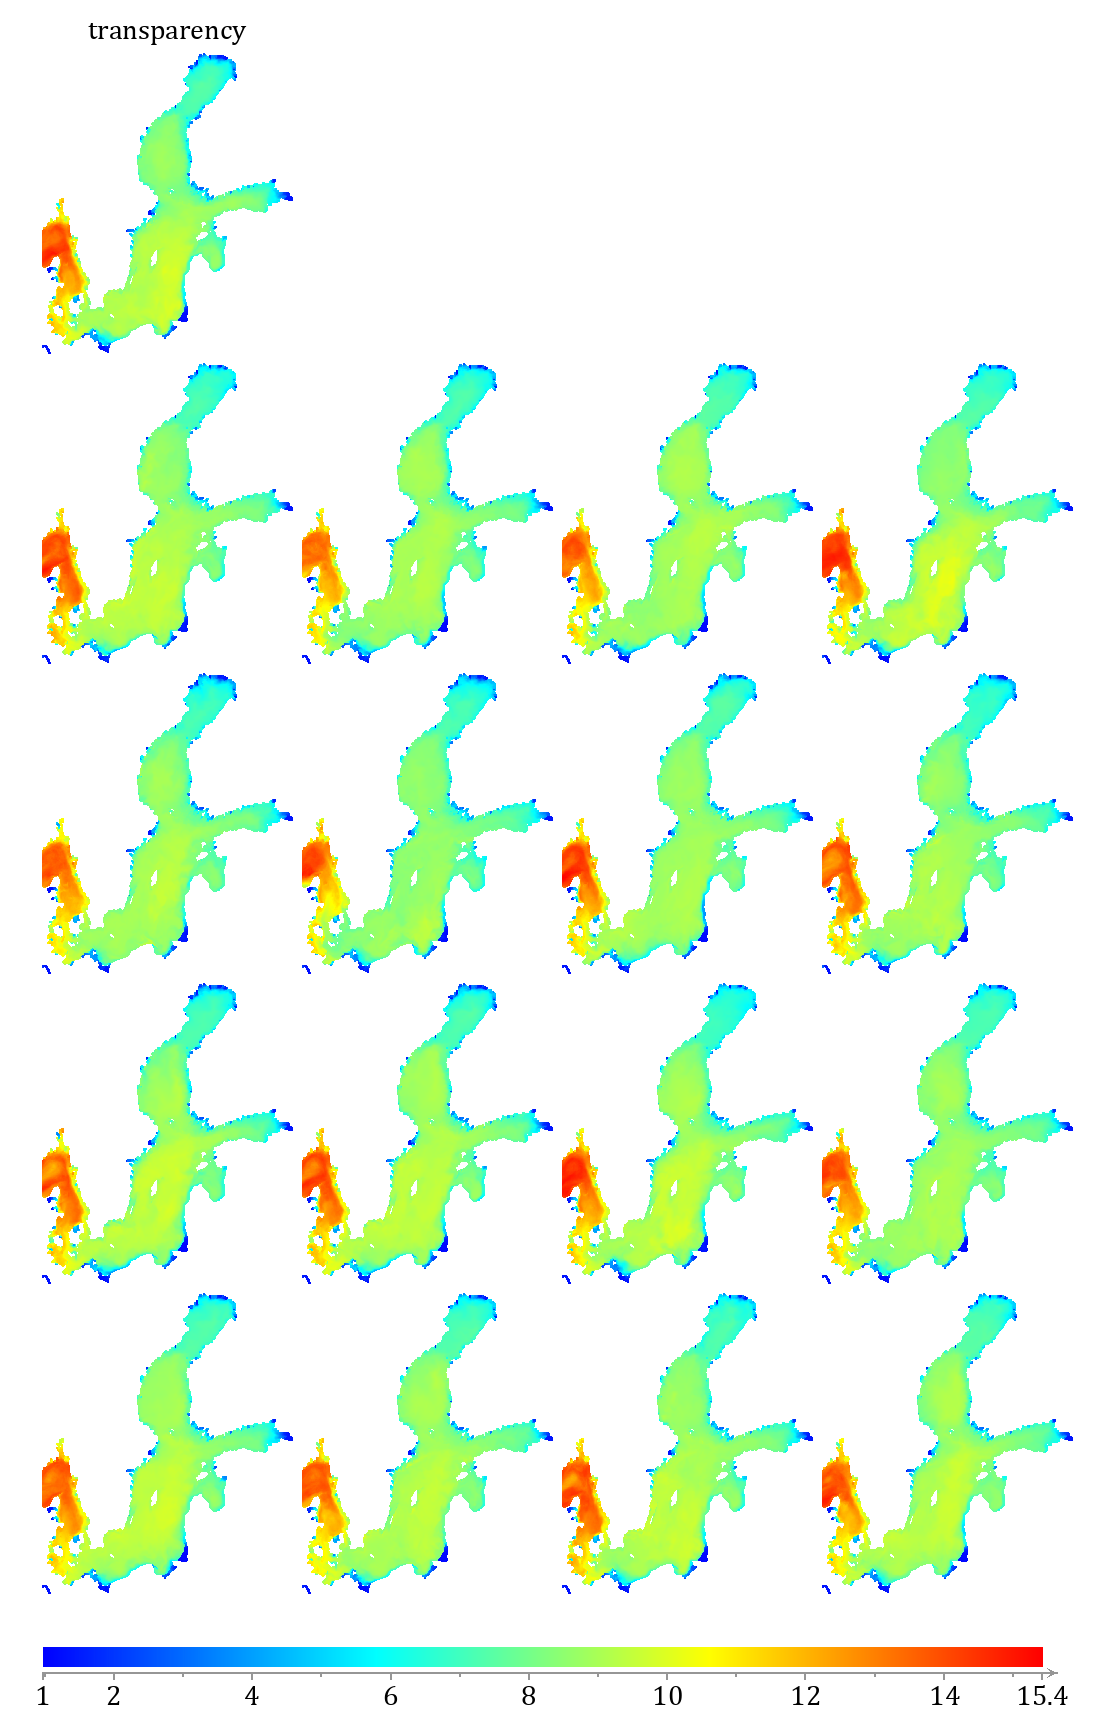

In [5]:
def show_raw_covs():
    P = artist.Panel(250, 300)

    for year in YEARS:
        if (var, year) not in RAW_DATA_MEAN: continue
        FLAT, COORDS = RAW_DATA_MEAN[var, year]
        x, y = (year-2007) % 4, (year-2007) // 4
        P.points(COORDS, colors=FLAT, p=1).move(x*260, y*310)
    
    P.C.fit(1)
    P.C.grad = 'heat'
    P.top = var
    return (P / P.color_axis('v', 1000, 20)).show()


show_raw_covs()

In [6]:
var = 'bottom_oxygen'
for year in YEARS:
    try:
        assert os.path.exists(f"/home/shubin/Downloads/obamanext/variables/{year}/{var}.nc")
        FLAT, COORDS = read_variable_as_flat_mean(year, var)
        RAW_DATA_MEAN[var, year] = FLAT, COORDS
    except:
        print(var, year, '!!!')

(47, 774, 763)
bottom_oxygen 2007 147134 2007-09-15--2007-10-31 -497.203369140625 -- 389.3223571777344
(47, 774, 763)
bottom_oxygen 2008 147134 2008-09-15--2008-10-31 -596.7376708984375 -- 391.1857604980469
(47, 774, 763)
bottom_oxygen 2009 147134 2009-09-15--2009-10-31 -453.32470703125 -- 401.53375244140625
(47, 774, 763)
bottom_oxygen 2010 147134 2010-09-15--2010-10-31 -288.31842041015625 -- 379.76458740234375
(47, 774, 763)
bottom_oxygen 2011 147134 2011-09-15--2011-10-31 -242.2202911376953 -- 376.5930480957031
(47, 774, 763)
bottom_oxygen 2012 147134 2012-09-15--2012-10-31 -266.05963134765625 -- 386.70574951171875
(47, 774, 763)
bottom_oxygen 2013 147134 2013-09-15--2013-10-31 -267.04052734375 -- 376.9226379394531
(47, 774, 763)
bottom_oxygen 2014 147134 2014-09-15--2014-10-31 -280.4958801269531 -- 390.6658020019531
(47, 774, 763)
bottom_oxygen 2015 147134 2015-09-15--2015-10-31 -322.5623474121094 -- 395.69488525390625
(47, 774, 763)
bottom_oxygen 2016 147134 2016-09-15--2016-10-31

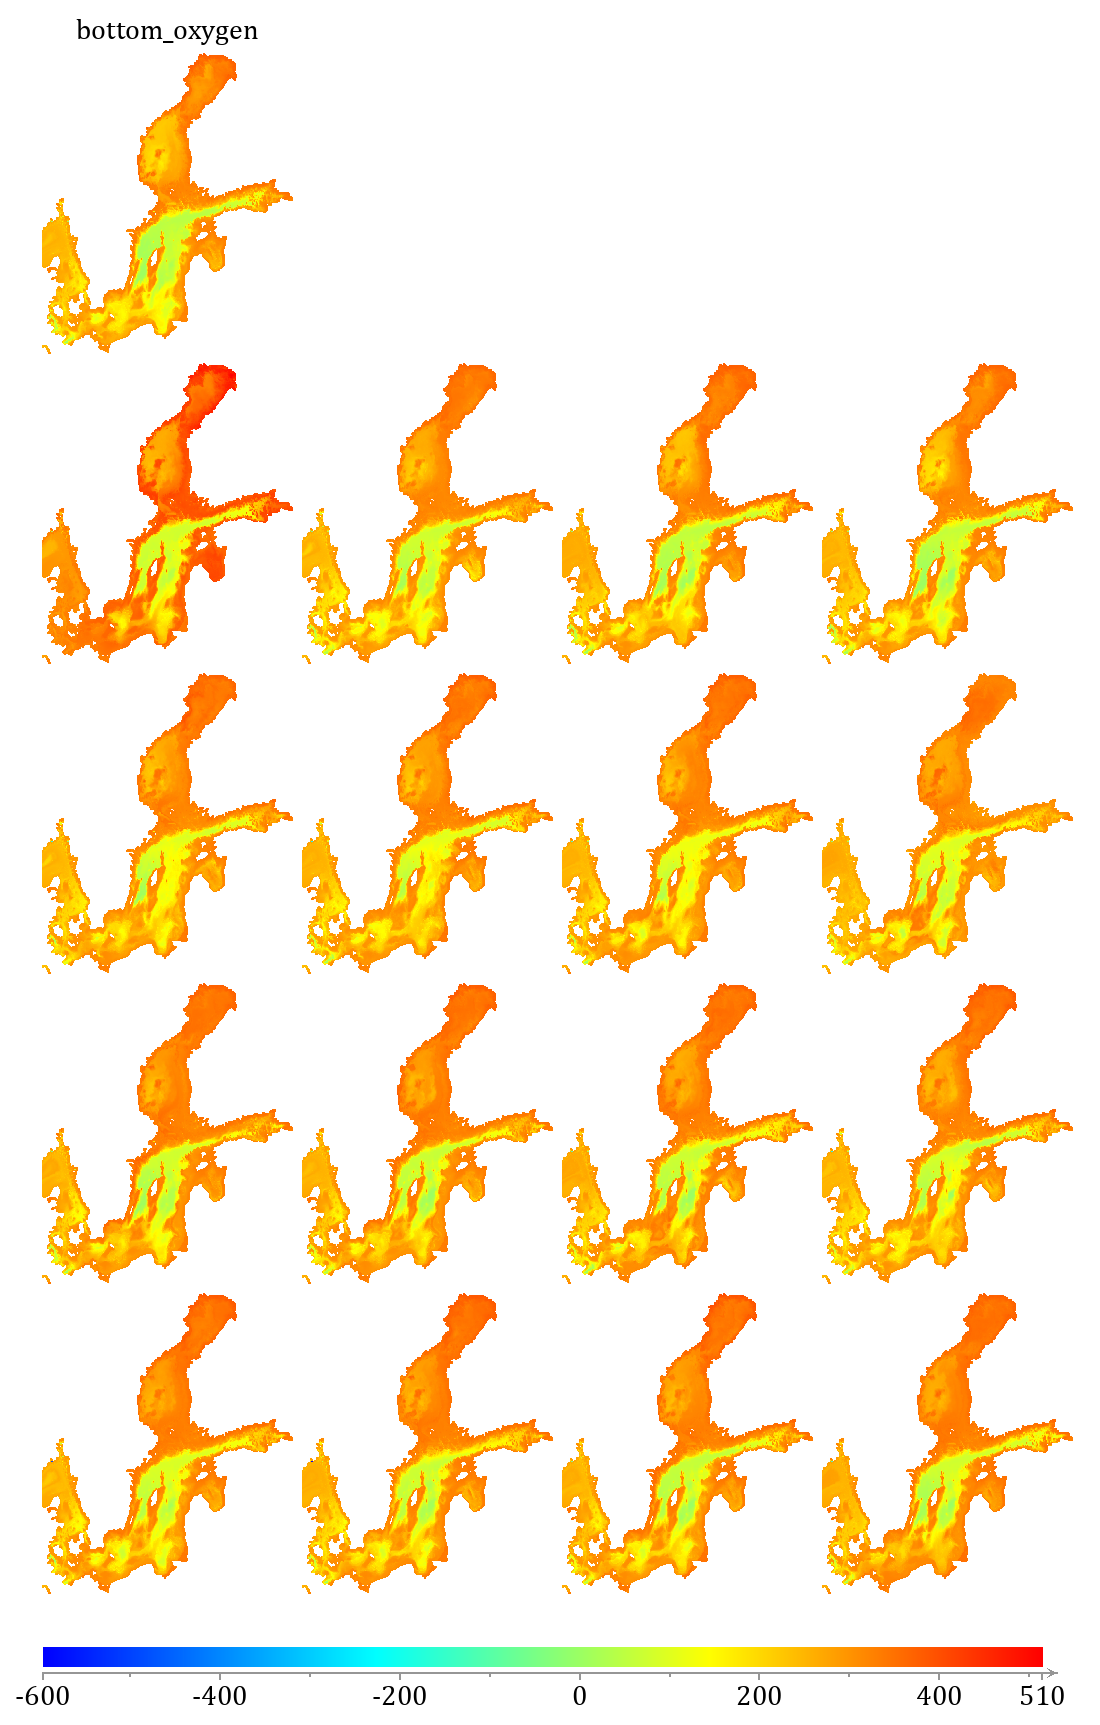

In [7]:
show_raw_covs()

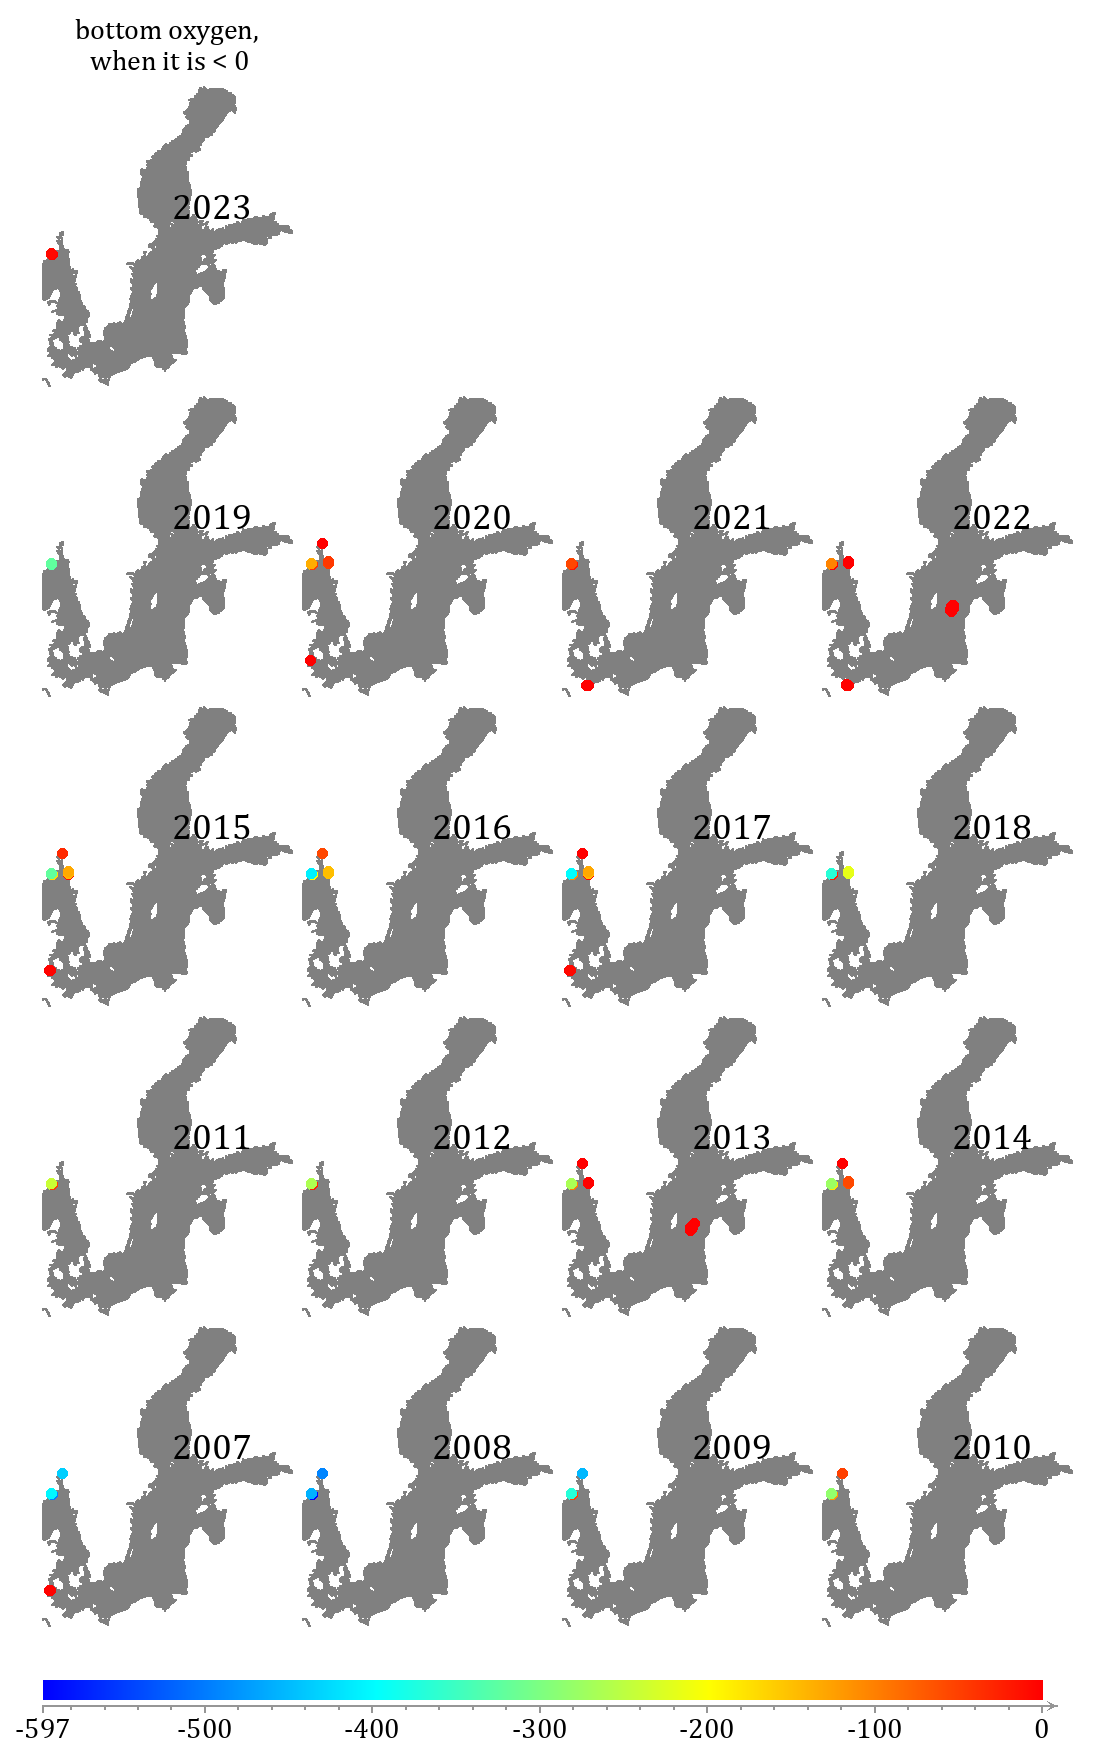

In [8]:
P = artist.Panel(250, 300)
var = 'bottom_oxygen'

for year in YEARS:
    FLAT, COORDS = RAW_DATA_MEAN[var, year]
    x, y = (year-2007) % 4, (year-2007) // 4
    inds = [i for i, x in enumerate(FLAT) if x < 0]
    P.points(COORDS, col='__k', p=1).move(x*260, y*310)
    P.points([COORDS[i] for i in inds], colors=[FLAT[i] for i in inds], p=10).move(x*260, y*310)
    P.text(20, 60, str(year)).move(x*260, y*310)

P.C.fit(1)
P.C.grad = 'heat'
P.top = 'bottom oxygen,\n when it is < 0'
(P / P.color_axis('v', 1000, 20)).show()

In [9]:
# remove negative values
var = 'bottom_oxygen'

for year in YEARS:
    FLAT, COORDS = RAW_DATA_MEAN[var, year]
    FLAT = [max(x, 0) for x in FLAT]
    RAW_DATA_MEAN[var, year] = FLAT, COORDS

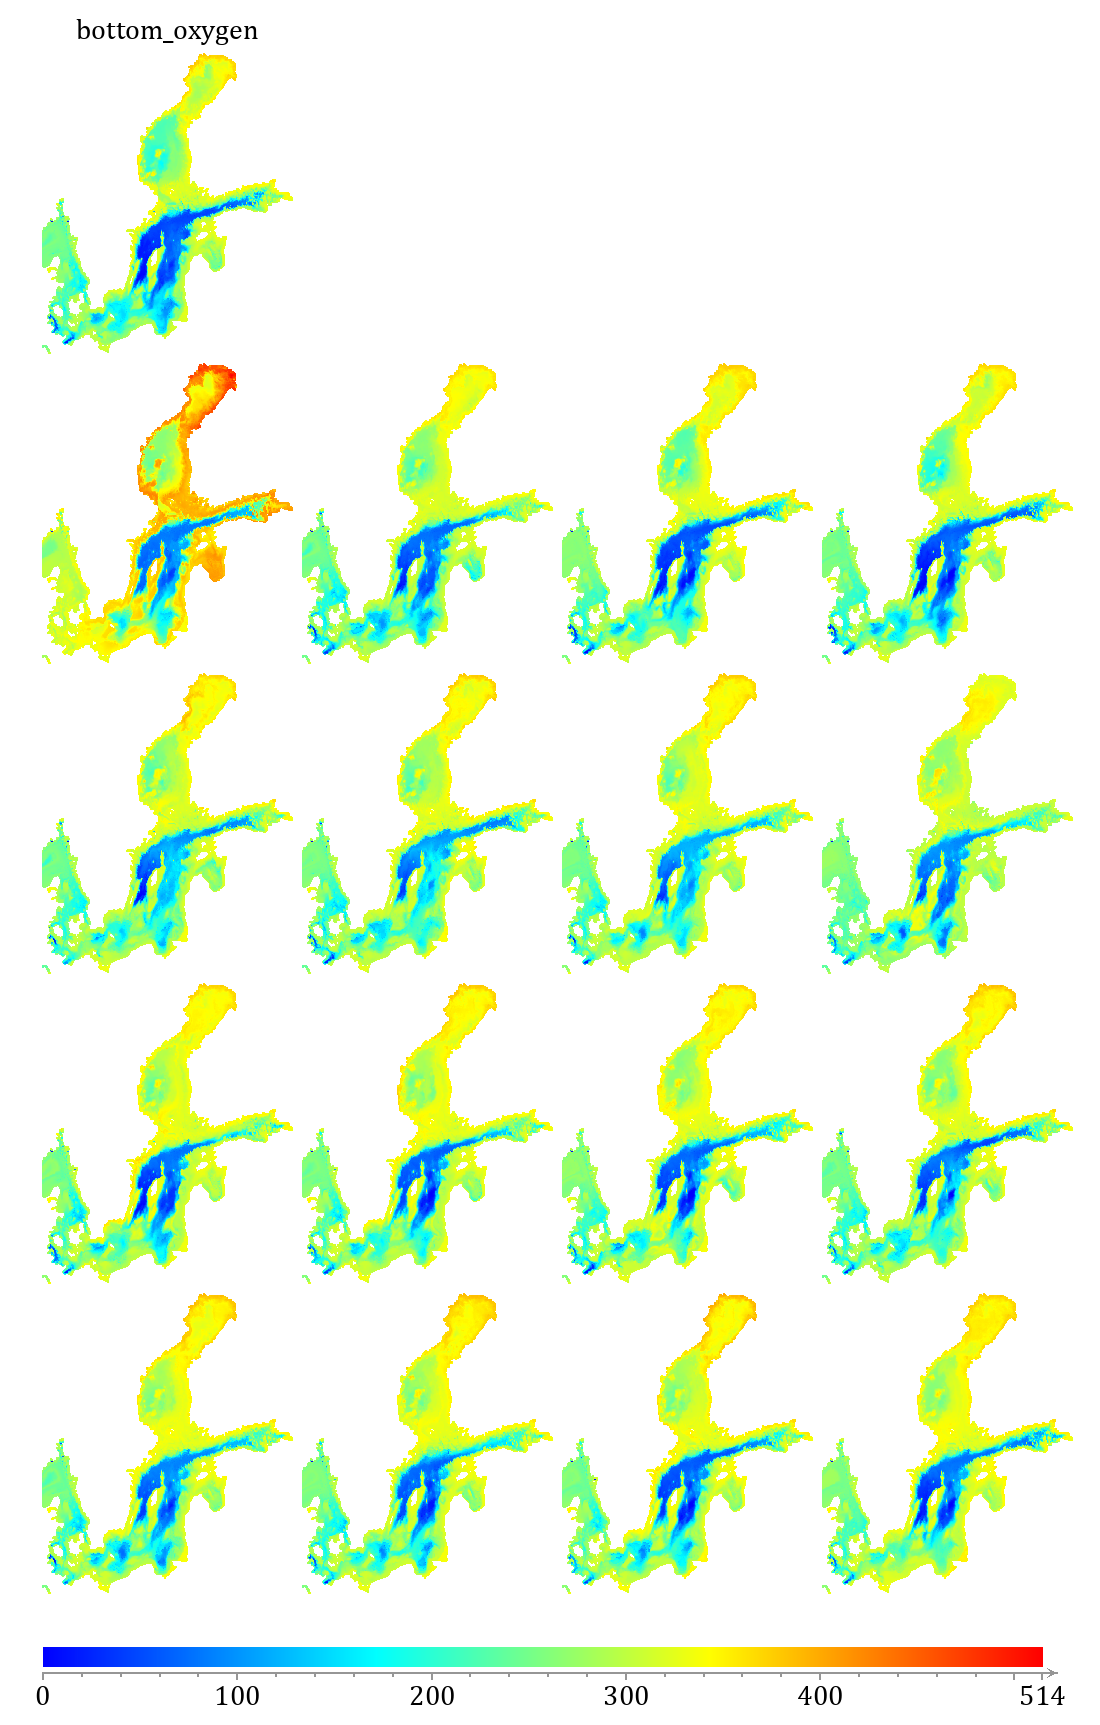

In [10]:
show_raw_covs()

# Infer the coords numbers

In [11]:
for k, (flat, coords) in RAW_DATA_MEAN.items():
    print(k, len(coords))

('transparency', 2007) 147134
('transparency', 2008) 147133
('transparency', 2009) 147133
('transparency', 2010) 147133
('transparency', 2011) 147133
('transparency', 2012) 147133
('transparency', 2013) 147133
('transparency', 2014) 147133
('transparency', 2015) 147134
('transparency', 2016) 147134
('transparency', 2017) 147134
('transparency', 2018) 147134
('transparency', 2019) 147134
('transparency', 2020) 147134
('transparency', 2021) 147134
('transparency', 2022) 147134
('transparency', 2023) 147134
('bottom_oxygen', 2007) 147134
('bottom_oxygen', 2008) 147134
('bottom_oxygen', 2009) 147134
('bottom_oxygen', 2010) 147134
('bottom_oxygen', 2011) 147134
('bottom_oxygen', 2012) 147134
('bottom_oxygen', 2013) 147134
('bottom_oxygen', 2014) 147134
('bottom_oxygen', 2015) 147134
('bottom_oxygen', 2016) 147134
('bottom_oxygen', 2017) 147134
('bottom_oxygen', 2018) 147134
('bottom_oxygen', 2019) 147134
('bottom_oxygen', 2020) 147134
('bottom_oxygen', 2021) 147134
('bottom_oxygen', 2022) 1

In [12]:
coords = {}
counts = {}
labels = {}
letters = 'ABCDEFG'
for _, COORDS in RAW_DATA_MEAN.values():
    COORDS = tuple(COORDS)
    if COORDS not in coords:
        l, *letters = letters
        n = len(COORDS)
        coords[COORDS] = (n, l)
        counts[n, l] = 1
        labels[n, l] = COORDS
    else:
        n, l = coords[COORDS]
        counts[n, l] += 1

counts

{(147134, 'A'): 20, (147133, 'B'): 7, (147134, 'C'): 7}

# Part 2

# We are ready to link the data

In [48]:
resolution, p = '5x5', 15

#resolution, p = '3x3', 9

#resolution, p = '1x1', 3



In [49]:
# load the data

M = pandas.read_csv(f'data/base_map_{resolution}.csv')
M = M[M.exclude < 5].reset_index(drop=True)
# we need to learn values for some excluded regions as well, as some data points lay inside excluded regions
M

,x_lon,y_lat,depth,dts,dto,reg,srn,exclude
0,10.731250,53.906250,1.0,0.926886,506.658314,22.0,36G0,3
1,11.281250,53.989583,6.0,1.879455,486.154431,22.0,36G1,3
2,13.893750,53.989583,4.0,1.235891,530.152157,24.0,36G3,3
3,14.031250,53.989583,4.0,1.235783,531.567022,24.0,36G4,3
4,14.168750,53.989583,10.0,2.471890,535.320496,24.0,36G4,3
...,...,...,...,...,...,...,...,...
4132,21.043750,63.656250,27.0,7.388360,1479.763951,NaN,56H1,3
4133,20.310417,63.739583,1.0,0.820205,1489.982307,NaN,56H0,3
4134,20.493750,63.739583,7.0,2.460614,1489.941976,NaN,56H0,3
4135,20.677083,63.739583,13.0,4.203874,1489.941976,NaN,56H0,3


In [50]:
closest = {}
    
def get_list_of_closest(COORDS):
    for COORDS, label in coords.items():

        X, Y = zip(*COORDS)
        X = list(sorted(set(X)))
        Y = list(sorted(set(Y)))

        closest_x = {x: X[read_data.closest_in_list(x, 0, X)] for x in M.x_lon.unique()}
        closest_y = {y: Y[read_data.closest_in_list(y, 0, Y)] for y in M.y_lat.unique()}


        def get_ind(x, y):
            xx = closest_x[x]
            yy = closest_y[y]
            try:
                return COORDS.index((xx, yy))
            except ValueError:
                # no immediate closest coord found
                return -1

        return M.apply(lambda row: get_ind(row.x_lon, row.y_lat), axis=1)
    

closest = {}
    
for COORDS, label in coords.items():
    print(label)
    closest[label] = get_list_of_closest(COORDS)
    
print('Done !')

(147134, 'A')
(147133, 'B')
(147134, 'C')
Done !


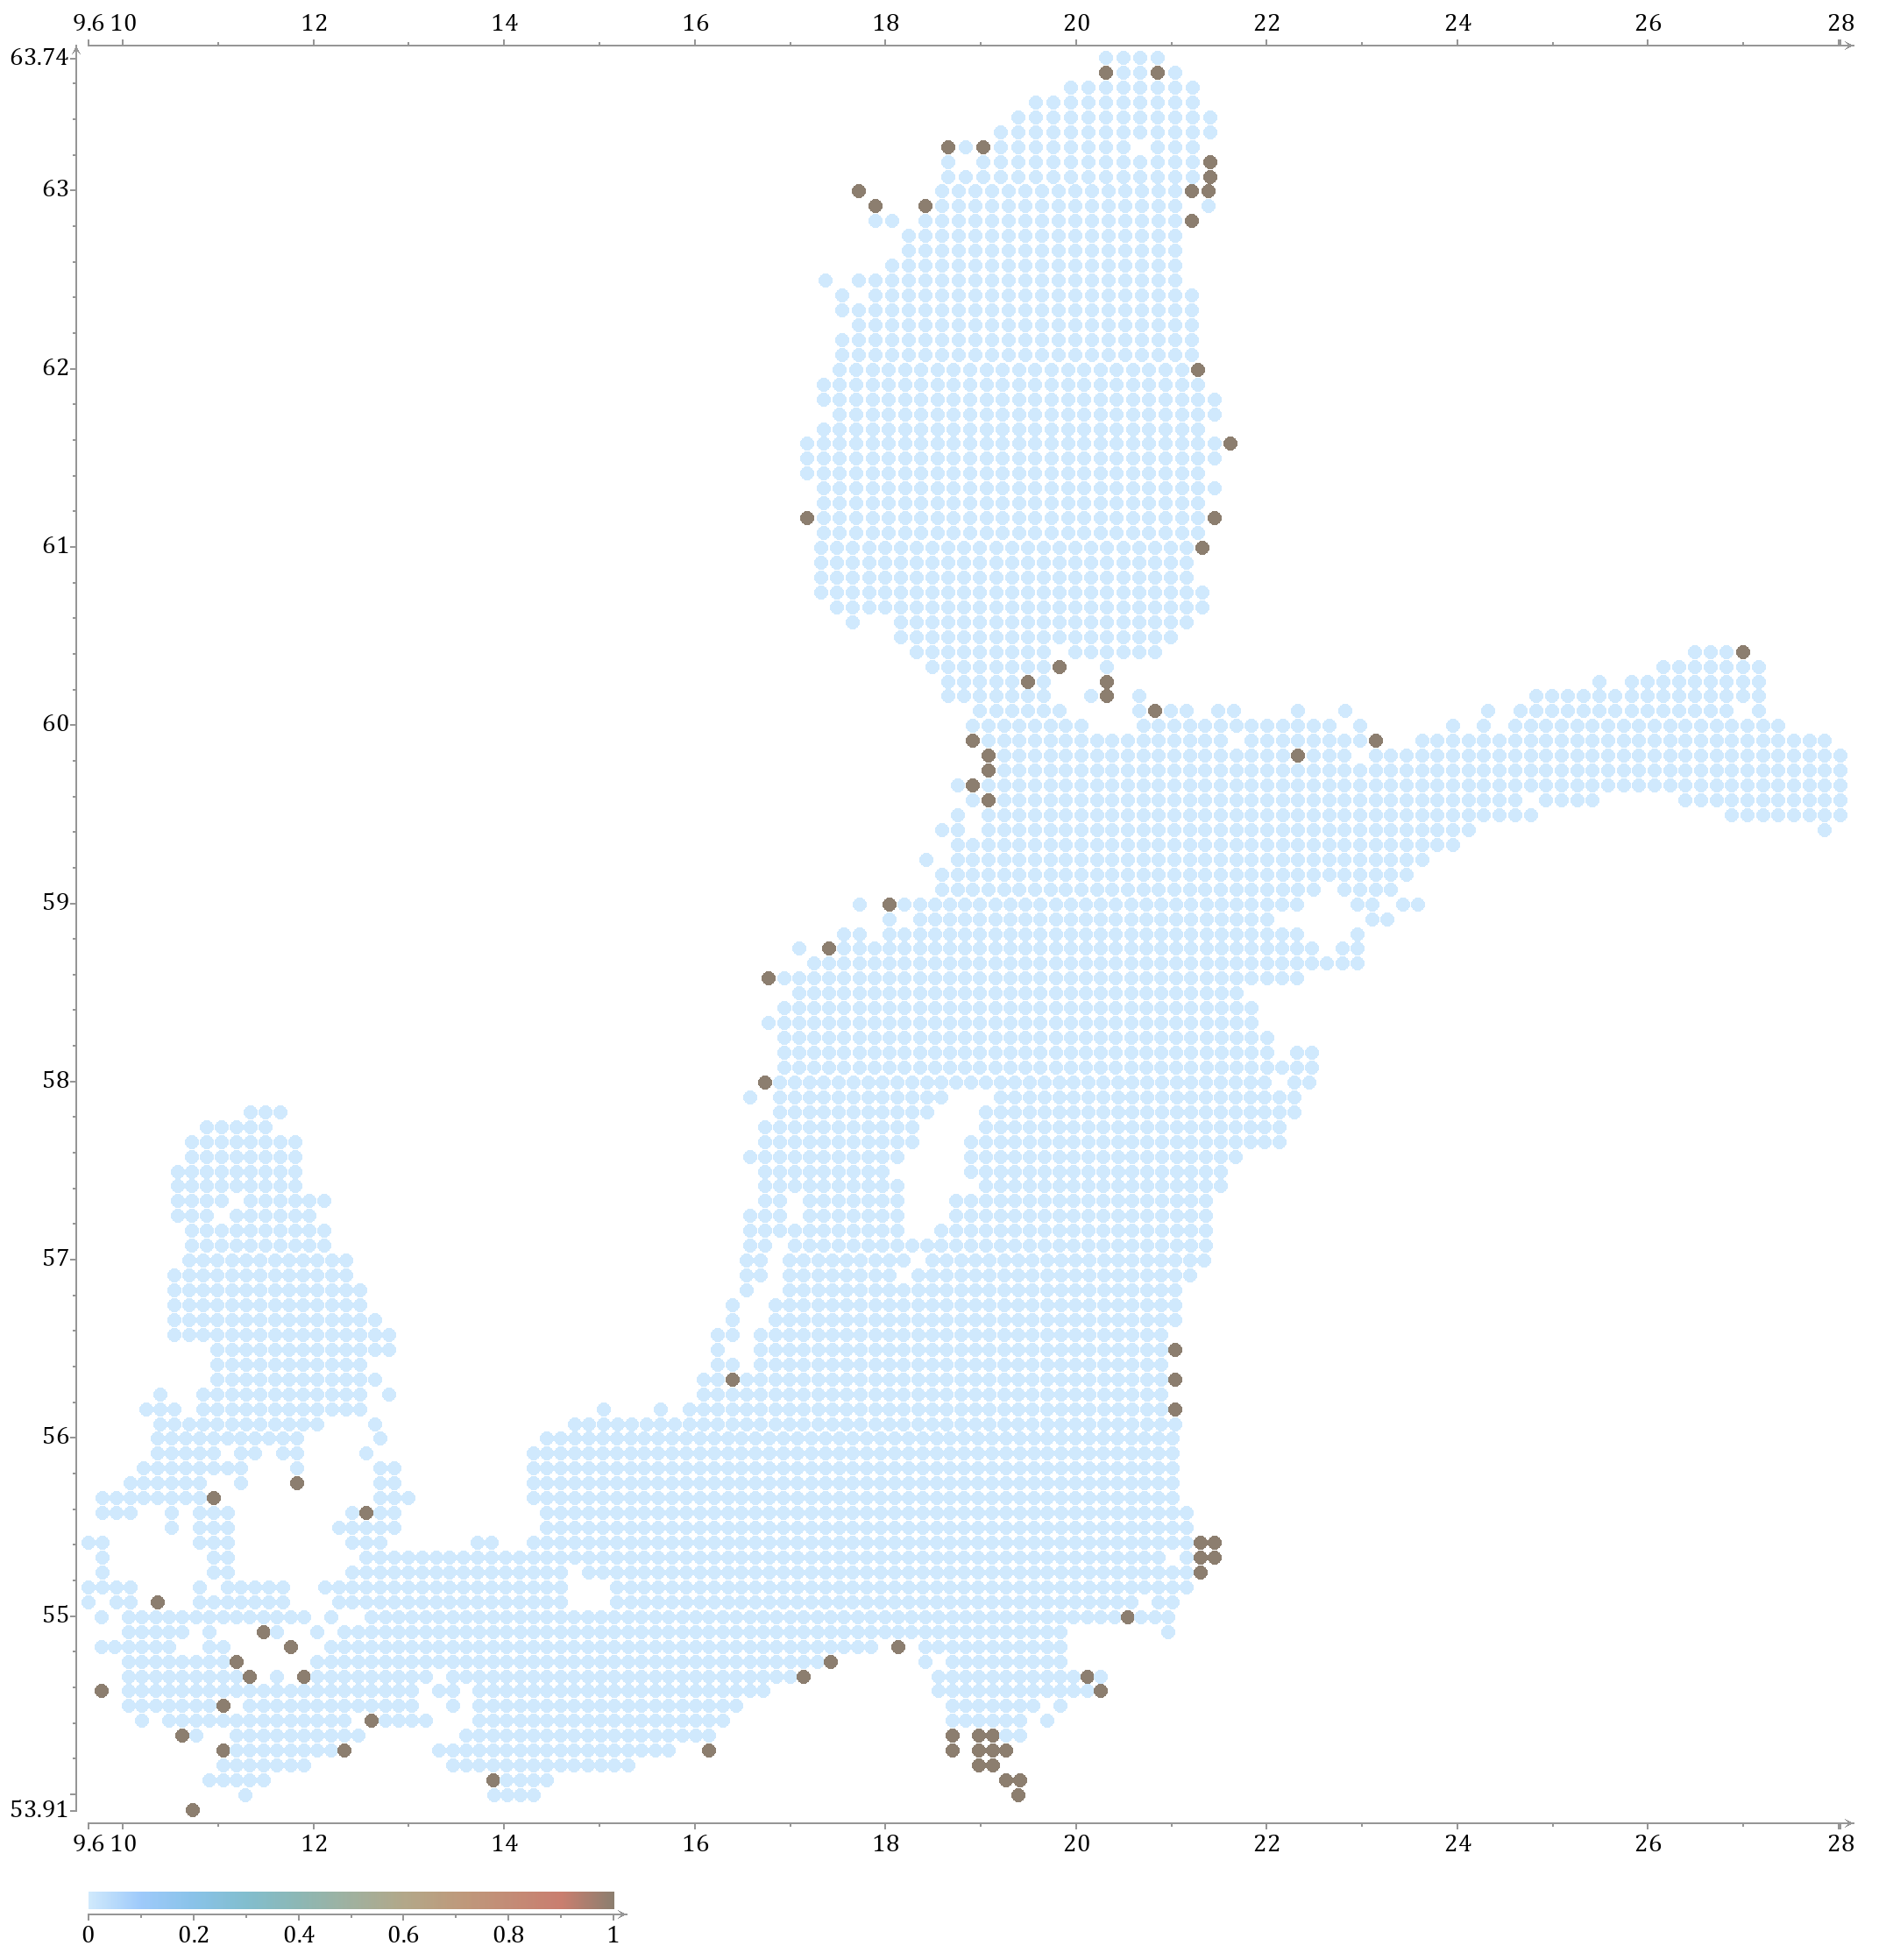

In [51]:
label = (147134, 'A')

P = artist.Panel(2000, 2000, 'v^<<', C=1)

P.points(M.x_lon, M.y_lat, colors=closest[label]==-1, p=p)
P.C.grad = '_+fish'
(P/P.color_axis('v', 600, 20)).show()


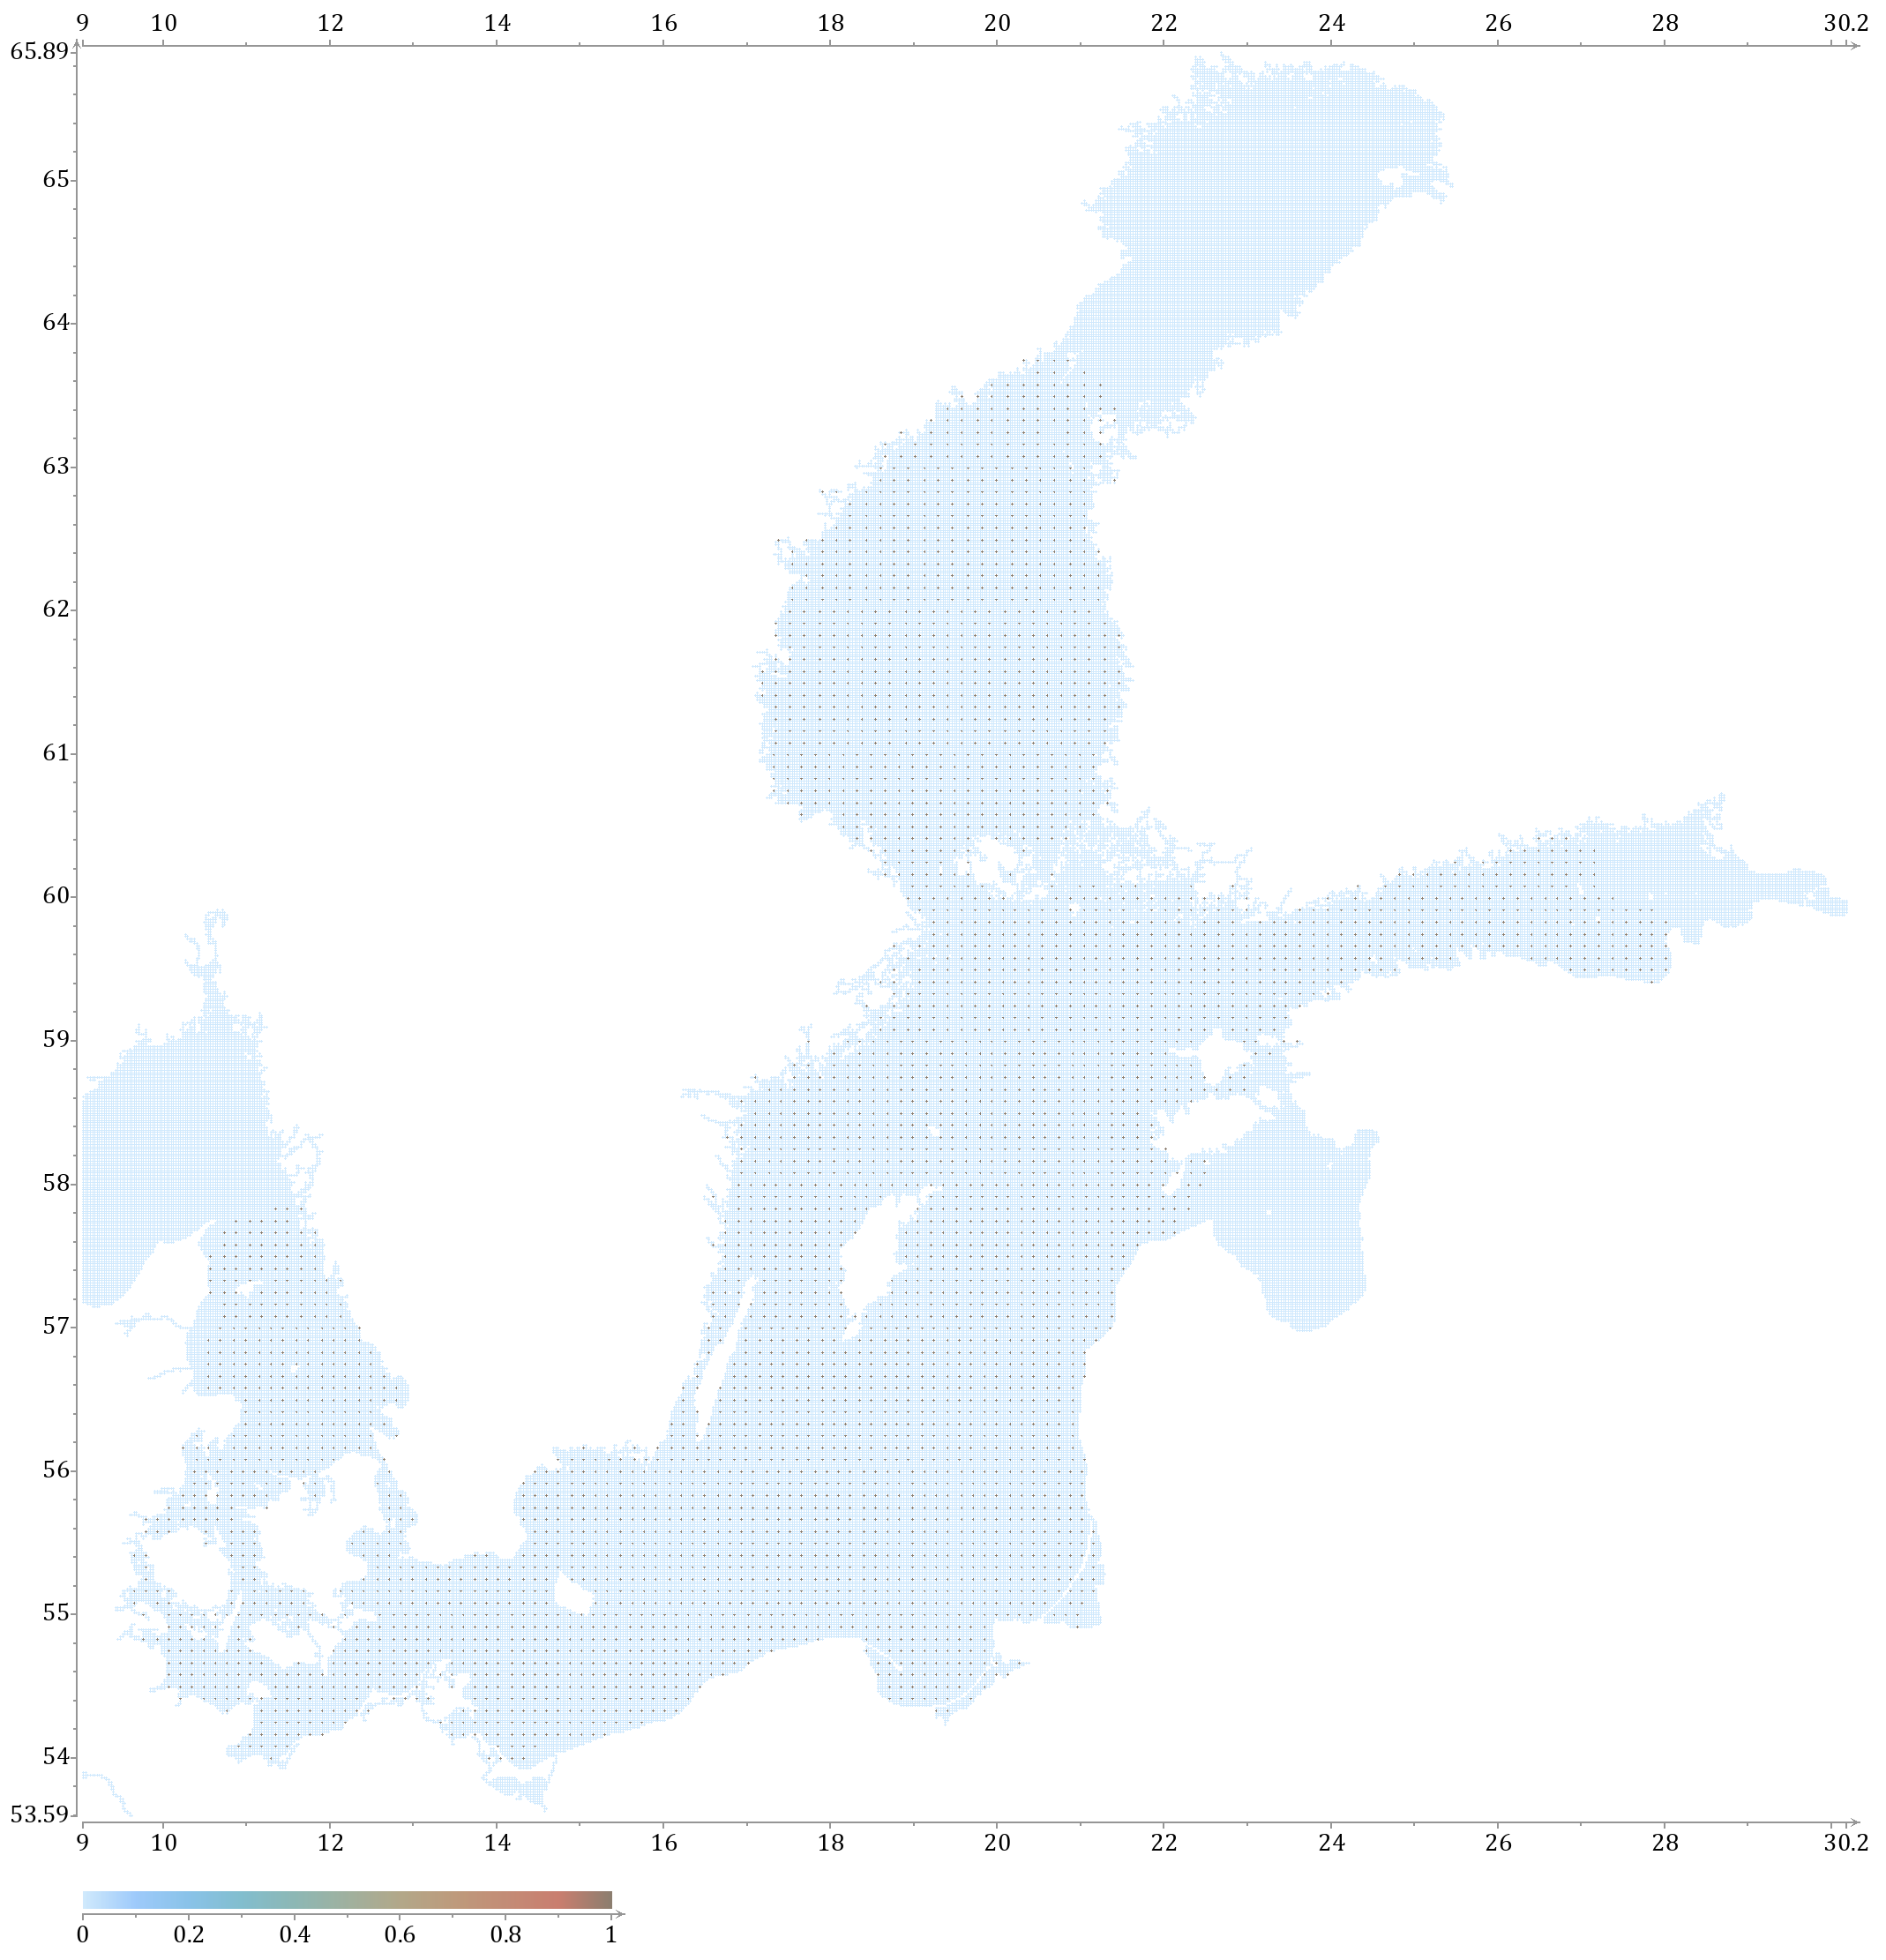

In [52]:
P = artist.Panel(2000, 2000, 'v^<<', C=1)

COORDS = labels[label]

used_coords = [0]*len(COORDS)
for i in closest[label]:
    if i >= 0:
        used_coords[i] += 1

P.points(COORDS, colors=used_coords, p=2)
P.C.grad = '_+fish'
(P/P.color_axis('v', 600, 20)).show()


In [53]:
for lab, c in closest.items():
    print(lab, sum((c==-1) & (M.exclude==0)))
    M.loc[(c==-1) & (M.exclude==0), 'exclude'] = 11
    

(147134, 'A') 0
(147133, 'B') 0
(147134, 'C') 0


In [54]:
M.exclude.unique()

array([3, 0])

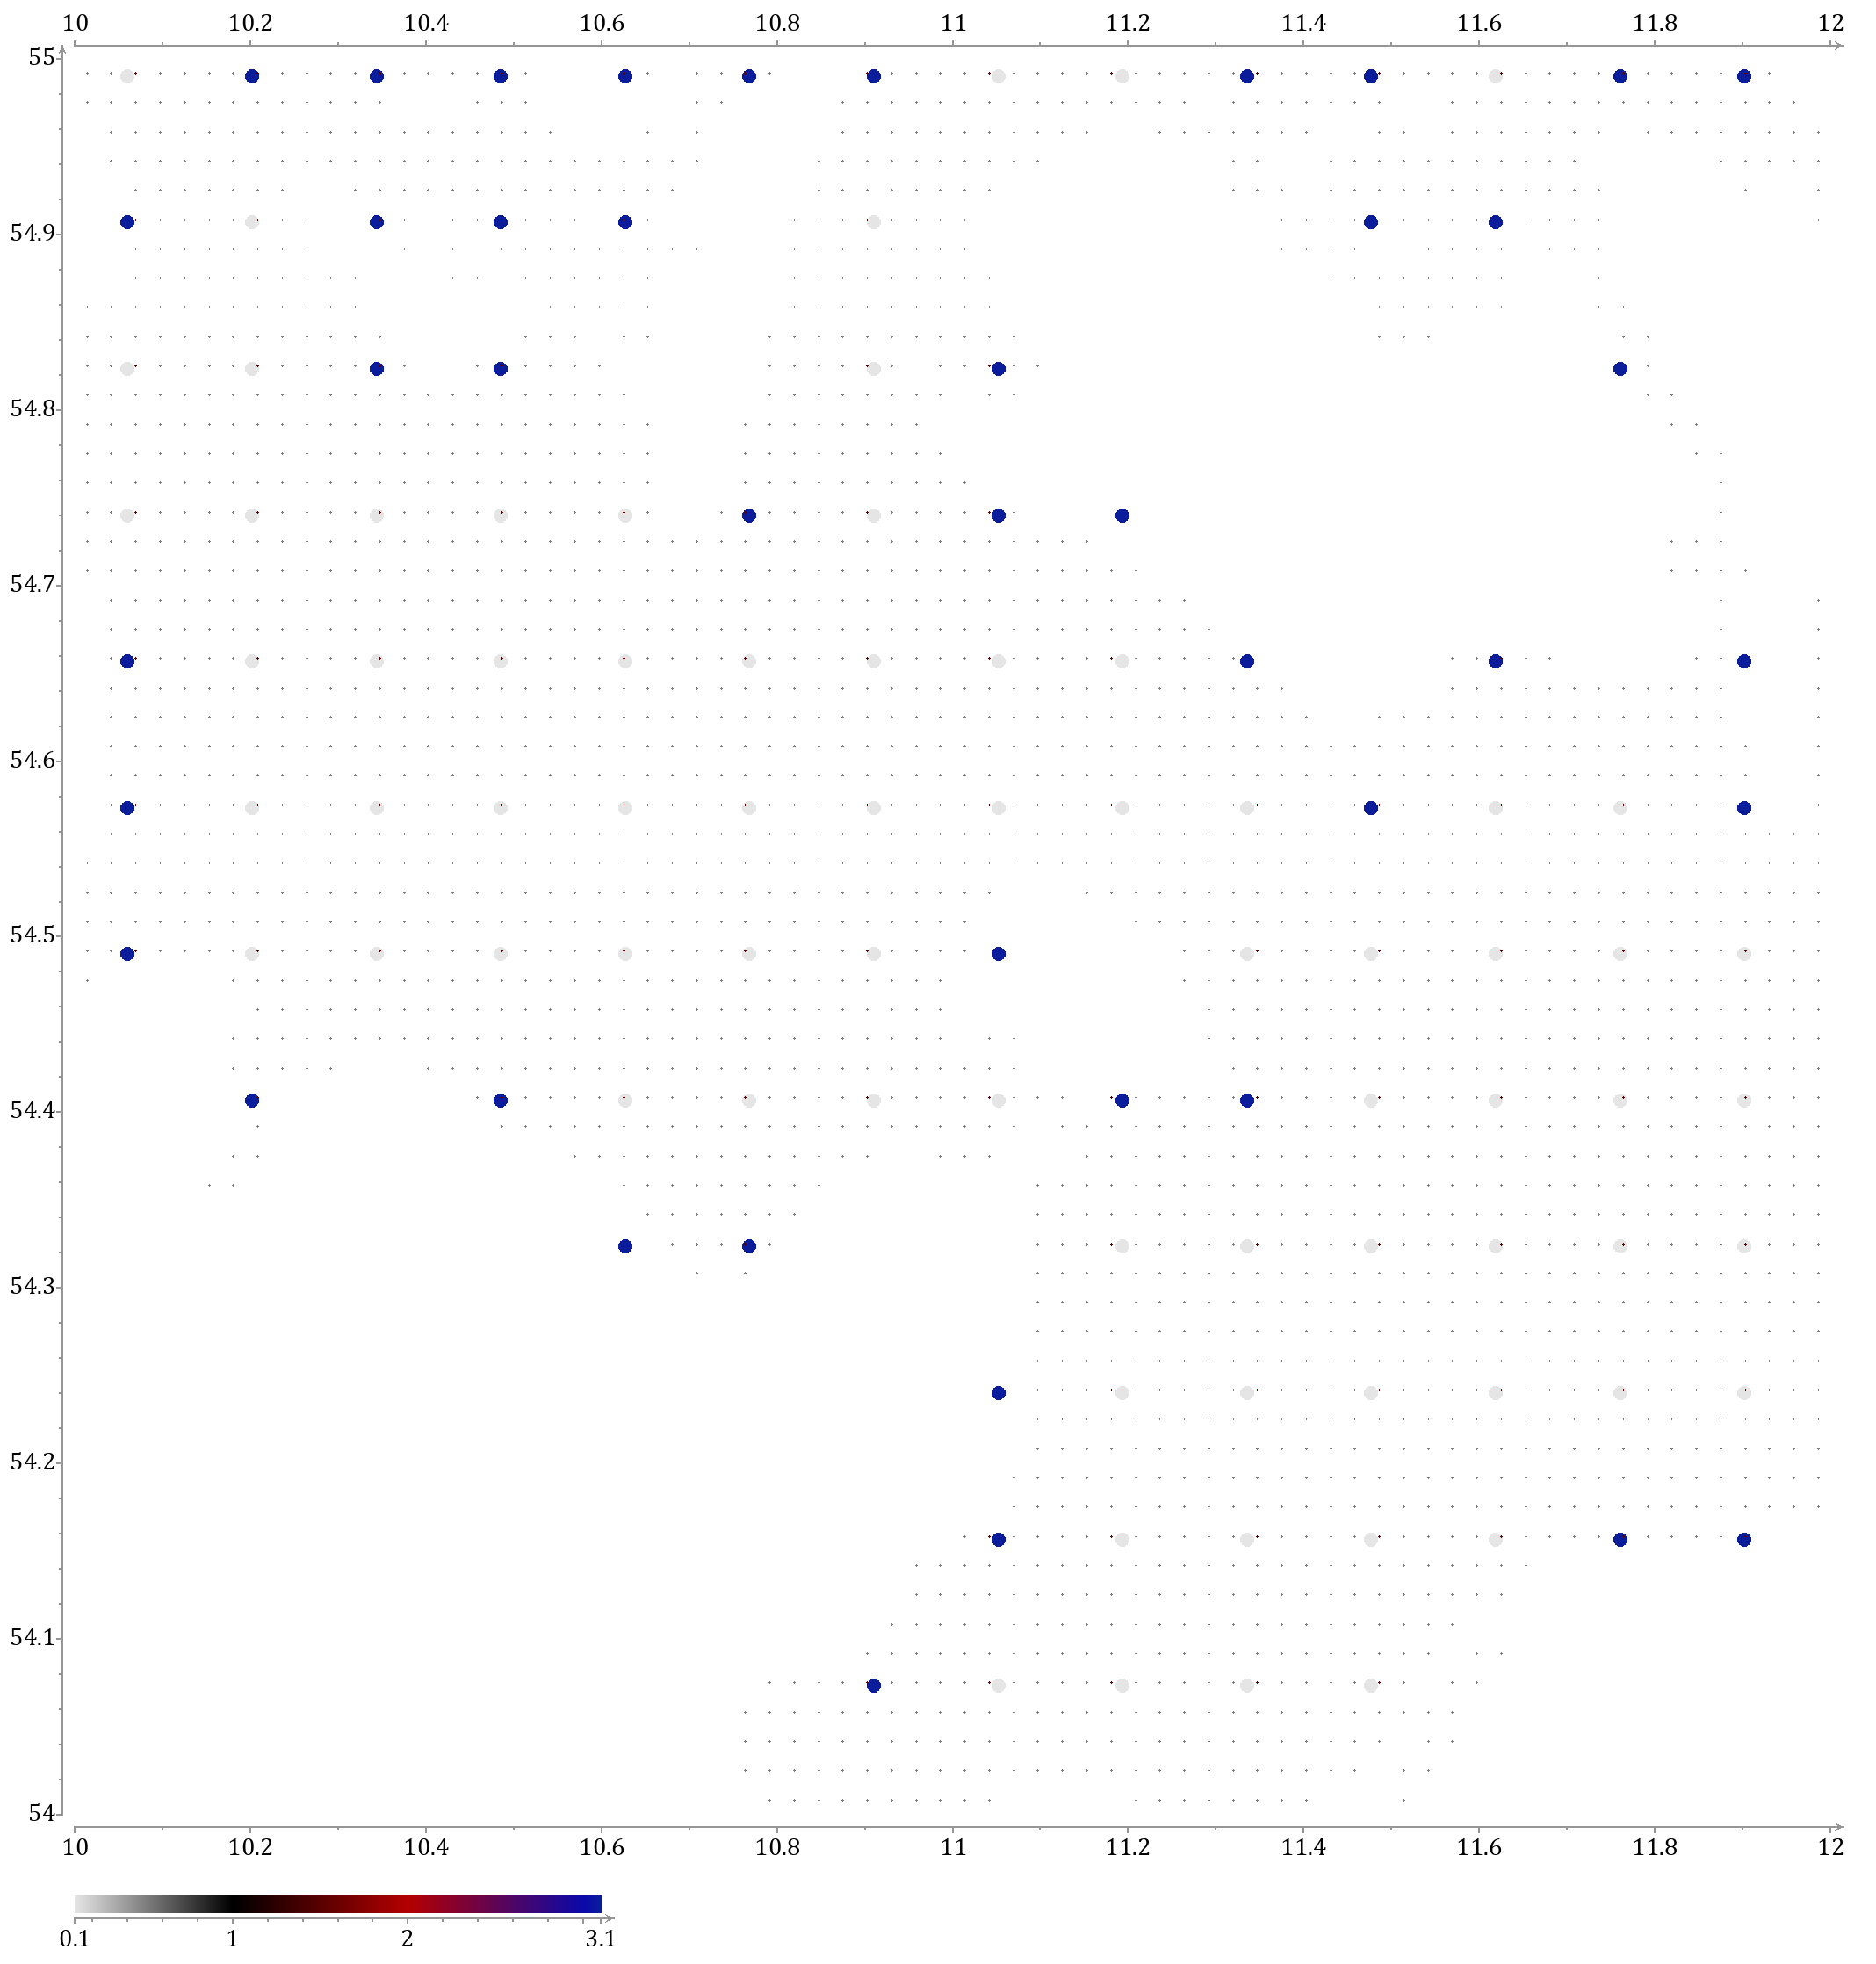

In [55]:
P = artist.Panel((10, 12, 2000), (54, 55, 2000), 'v^<<')

P.points(M.x_lon, M.y_lat, colors=M.exclude+0.1, p=p)
P.points(COORDS, colors=array(used_coords)+0.5, p=2)
(P/P.color_axis('v', 600, 20)).show()

In [56]:
CV = M[['x_lon', 'y_lat', 'exclude']][M.exclude < 5].reset_index(drop=True)
# we need to keep exluded points, so we can assign covariates to the observations


existing_closest = {}
for lab, c in closest.items():
    existing_closest[lab] = c[M.exclude < 5].reset_index(drop=True)

# Save the map of included points, for whom it is possible to get covariates

In [57]:
# save the map with the newly exluded points
PM = M[M.exclude == 0].drop(columns='exclude').reset_index(drop=True)
PM.to_csv(f'data/prediction_area_map_{resolution}.csv', index=False)

In [58]:
PM

,x_lon,y_lat,depth,dts,dto,reg,srn
0,14.306250,53.989583,11.0,7.810682,539.978247,24.0,36G4
1,11.052083,54.072917,23.0,6.935035,476.001952,22.0,37G1
2,11.193750,54.072917,22.0,6.539359,475.976407,22.0,37G1
3,11.335417,54.072917,10.0,8.464503,475.976407,22.0,37G1
4,11.477083,54.072917,6.0,3.263132,475.976407,22.0,37G1
...,...,...,...,...,...,...,...
3061,20.677083,63.489583,32.0,12.737461,1460.317065,30.0,55H0
3062,20.860417,63.489583,14.0,11.869755,1460.317065,30.0,55H0
3063,20.493750,63.572917,36.0,12.170933,1470.495090,NaN,56H0
3064,21.043750,63.572917,30.0,12.678795,1470.495090,NaN,56H1


In [59]:
len(M), len(PM), sum(CV.exclude==0)

(4137, 3066, 3066)

# Load covariates

In [60]:
VARS = 'transparency', 'bottom_oxygen'

In [61]:
CV_YEARS = []

for year in YEARS:
    AYC = CV.copy()
    AYC['year'] = year
    for var in VARS:
        FLAT, COORDS = RAW_DATA_MEAN[var, year]
        CLOSEST = existing_closest[coords[tuple(COORDS)]]
        AYC[var] = CLOSEST.apply(lambda j: FLAT[j])
        
    CV_YEARS.append(AYC)
    #AY = pandas.concat([AY, AYC]).reset_index(drop=True)

AY = pandas.concat(CV_YEARS).reset_index(drop=True)
AY


,x_lon,y_lat,exclude,year,transparency,bottom_oxygen
0,10.731250,53.906250,3,2007,2.753679,387.900635
1,11.281250,53.989583,3,2007,10.105822,290.234406
2,13.893750,53.989583,3,2007,1.888816,339.116119
3,14.031250,53.989583,3,2007,2.327153,335.533691
4,14.168750,53.989583,3,2007,5.296288,312.048370
...,...,...,...,...,...,...
70324,21.043750,63.656250,3,2023,7.150172,340.920441
70325,20.310417,63.739583,3,2023,1.351888,364.486084
70326,20.493750,63.739583,3,2023,6.539907,347.167542
70327,20.677083,63.739583,3,2023,6.865841,339.863373


# Save all covariates

In [62]:
AY.to_csv(f'data/part_of_annual_map_{resolution}.csv', index=False)

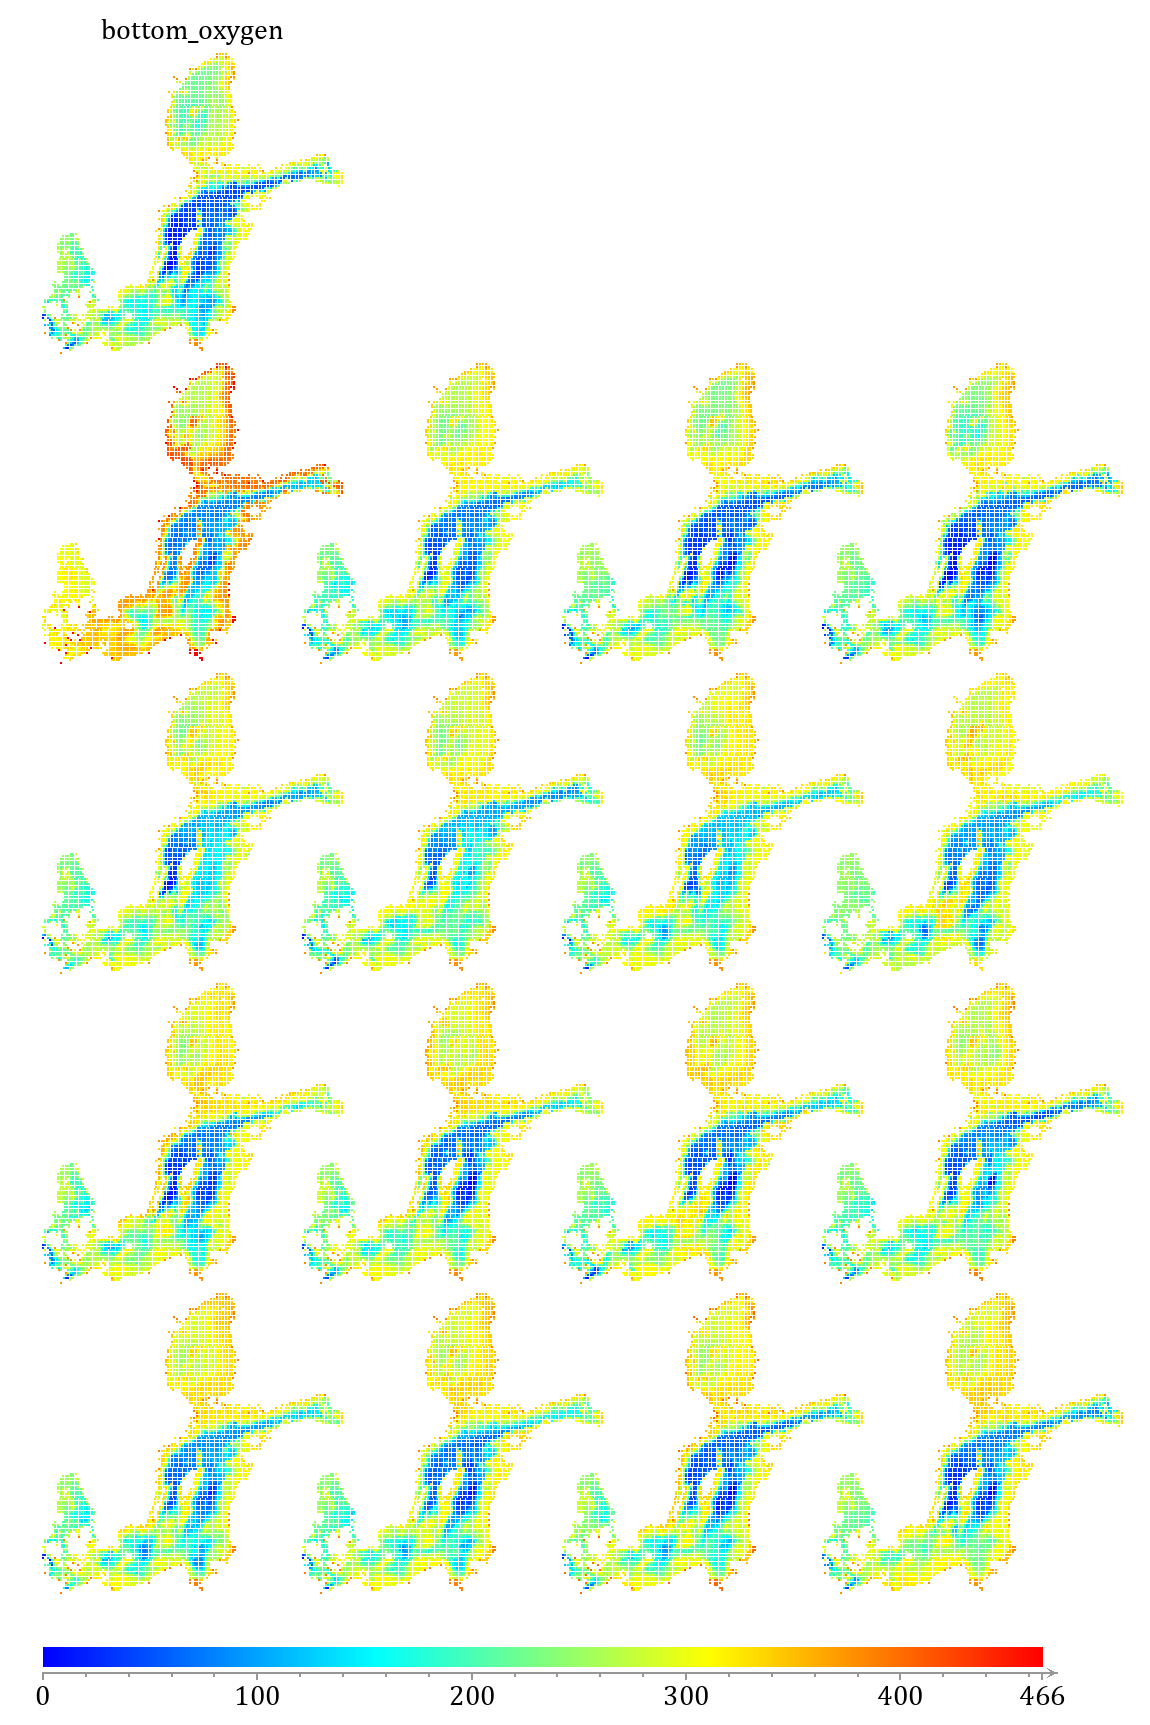

In [63]:
def show_covs(var):
    P = artist.Panel(300, 300)

    for year, C in AY.groupby('year'):
        x, y = (year-2007) % 4, (year-2007) // 4
        P.points(C.x_lon, C.y_lat, colors=C[var], p=1).move(x*260, y*310)
    
    P.C.fit(1)
    P.C.grad = 'heat'
    P.top = var
    return (P / P.color_axis('v', 1000, 20)).show()


show_covs('bottom_oxygen')

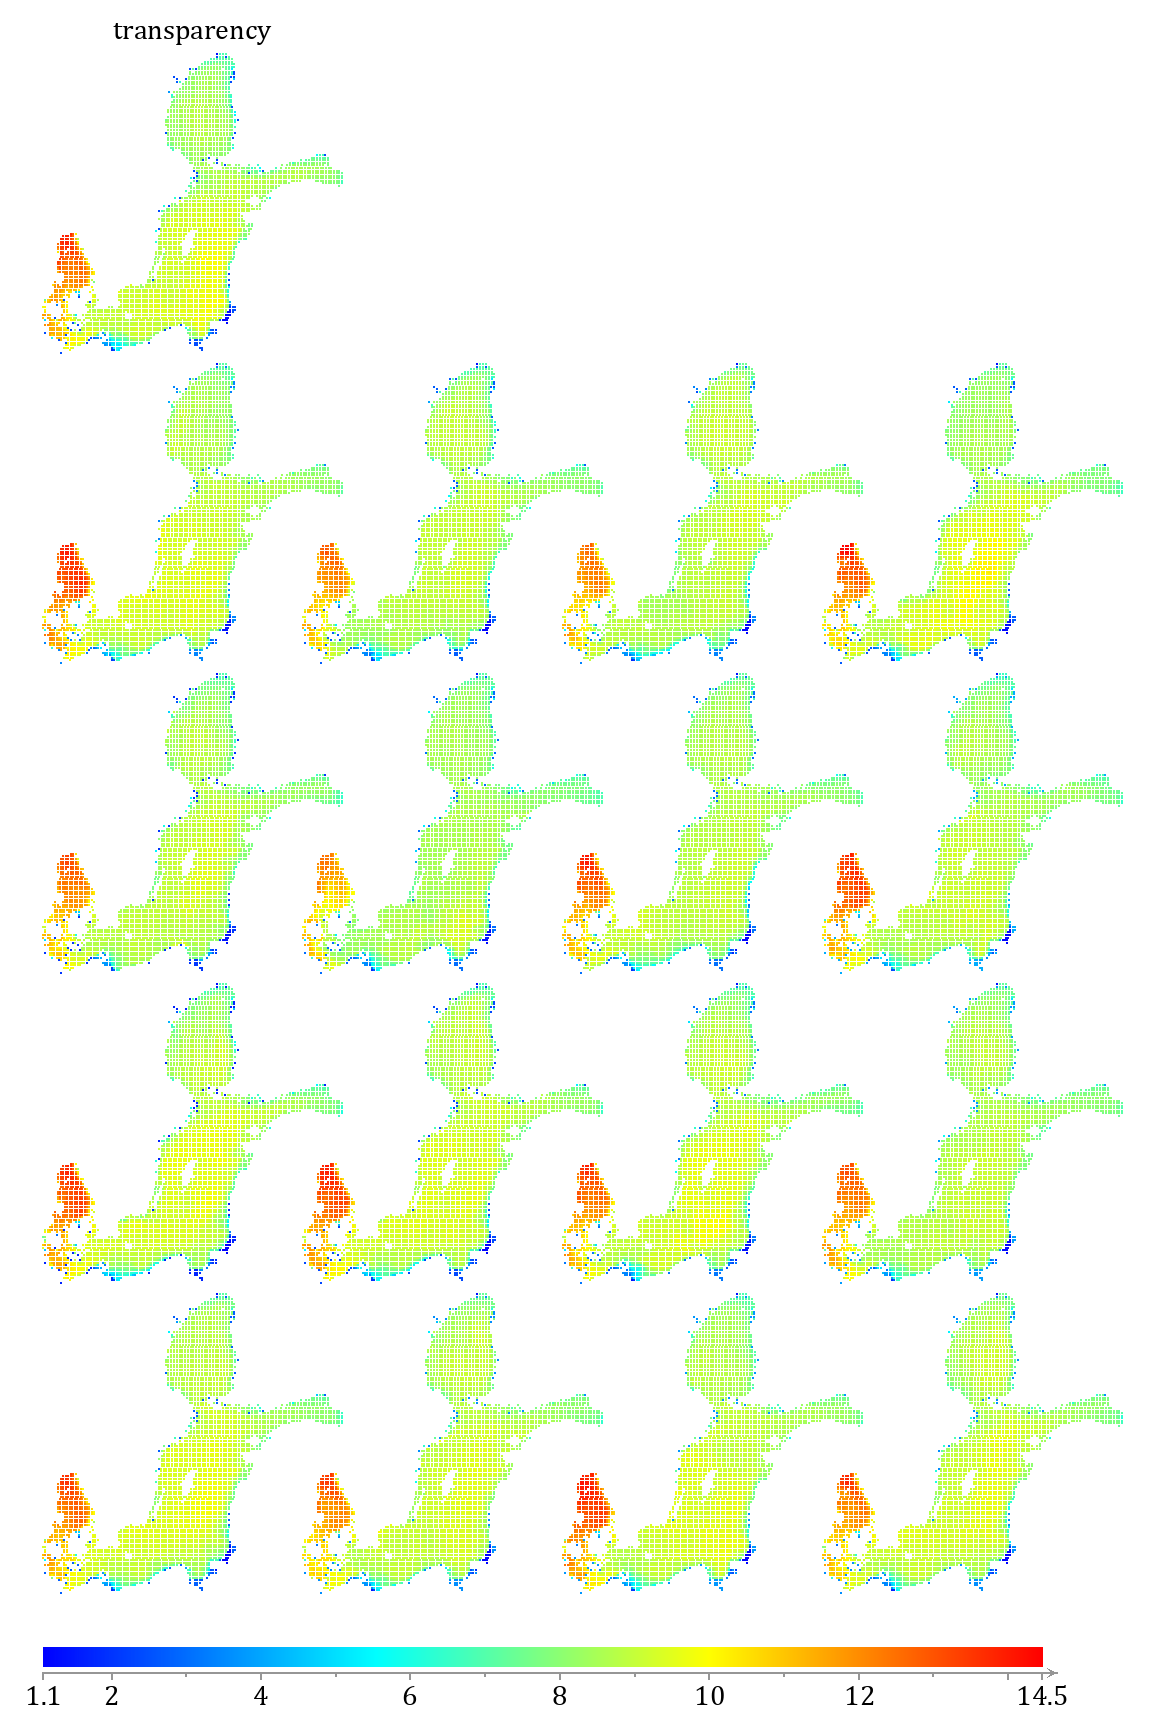

In [64]:
show_covs('transparency')